In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
!pip install catboost
from catboost import CatBoostClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Load data
file_path = 'lithium-ion batteries.csv'
df = pd.read_csv(file_path)

# Drop leakage-heavy or disallowed columns
for col in ['Spacegroup']:
    if col in df.columns:
        df = df.drop(columns=[col])

# Target
TARGET = 'Crystal System'
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Encode target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split columns
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object']).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), cat_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

models = {
    'Logistic Regression': LogisticRegression(max_iter=3000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Extra Trees': ExtraTreesClassifier(),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(probability=True),
    'Gradient Boosting': GradientBoostingClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'Naive Bayes': GaussianNB(),
    'XGBoost': XGBClassifier(eval_metric='mlogloss'),
    'CatBoost': CatBoostClassifier(verbose=0)
}

param_grids = {
    'Random Forest': {
        'model__n_estimators': [200, 400, 600],
        'model__max_depth': [10, 20, None],
        'model__min_samples_split': [2, 5, 10]
    },
        'Gradient Boosting': {
        'model__n_estimators': [100, 200, 300],
        'model__learning_rate': [0.03, 0.05, 0.1],
        'model__max_depth': [3, 5, 7]
    },
    'XGBoost': {
        'model__n_estimators': [200, 400],
        'model__max_depth': [4, 6, 8],
        'model__learning_rate': [0.03, 0.05, 0.1]
    },
    'CatBoost': {
        'model__depth': [4, 6, 8],
        'model__learning_rate': [0.03, 0.05, 0.1],
        'model__iterations': [200, 400]
    }
}

results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    print(f'Running {name}...')

    pipe = ImbPipeline([
        ('prep', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', model)
    ])

    if name in param_grids:
        search = RandomizedSearchCV(
            pipe,
            param_distributions=param_grids[name],
            n_iter=10,
            cv=cv,
            scoring='accuracy',
            random_state=42,
            n_jobs=-1
        )
        search.fit(X_train, y_train)
        best_model = search.best_estimator_
    else:
        best_model = pipe.fit(X_train, y_train)

    y_pred = best_model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1': round(f1, 4)
    })

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
print('\nFinal optimized comparison without Spacegroup:')
print(results_df)

Running Logistic Regression...
Running Decision Tree...
Running Random Forest...
Running Extra Trees...
Running KNN...
Running SVM...
Running Gradient Boosting...
Running AdaBoost...
Running Naive Bayes...
Running XGBoost...
Running CatBoost...

Final optimized comparison without Spacegroup:
                  Model  Accuracy  Precision  Recall      F1
2         Random Forest    0.6765     0.6749  0.6765  0.6692
9               XGBoost    0.6471     0.6452  0.6471  0.6454
3           Extra Trees    0.6471     0.6666  0.6471  0.6220
10             CatBoost    0.6324     0.6294  0.6324  0.6302
7              AdaBoost    0.6176     0.6218  0.6176  0.6181
6     Gradient Boosting    0.6029     0.6101  0.6029  0.6033
1         Decision Tree    0.5882     0.5871  0.5882  0.5875
4                   KNN    0.5735     0.5733  0.5735  0.5684
5                   SVM    0.5294     0.5135  0.5294  0.5171
0   Logistic Regression    0.4706     0.4558  0.4706  0.4612
8           Naive Bayes    0.3529   

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

stack_model = StackingClassifier(
    estimators=[

        ('xgb', XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            eval_metric='mlogloss',
            random_state=42
        )),
        ('rf', RandomForestClassifier(
            n_estimators=500,
            random_state=42
        )),
        ('cat', CatBoostClassifier(
            iterations=300,
            depth=6,
            learning_rate=0.05,
            verbose=0
        ))
    ],
    final_estimator=LogisticRegression(max_iter=3000),
    cv=5,
    n_jobs=-1
)

stack_pipe = ImbPipeline([
    ('prep', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', stack_model)
])

stack_pipe.fit(X_train, y_train)
y_pred = stack_pipe.predict(X_test)
y_pred_proba = stack_pipe.predict_proba(X_test)

print("Stacking Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1:", f1_score(y_test, y_pred, average='weighted'))
print("ROC_AUC:", roc_auc_score(y_test, y_pred_proba, average='weighted', multi_class='ovr'))

Stacking Accuracy: 0.7205882352941176
Precision: 0.7204406493780307
Recall: 0.7205882352941176
F1: 0.7162153476676889
ROC_AUC: 0.8378579209461563


In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# =========================================================
# 1. LOAD DATA
# =========================================================
df = pd.read_csv("lithium-ion batteries.csv")

# =========================================================
# 2. DROP LEAKAGE / UNUSED COLUMNS
# =========================================================
drop_cols = []
for col in ["Spacegroup", "Materials Id"]:
    if col in df.columns:
        drop_cols.append(col)

if drop_cols:
    df = df.drop(columns=drop_cols)

# =========================================================
# 3. PARSE CHEMICAL FORMULA
# =========================================================
def parse_formula_counts(formula):
    tokens = re.findall(r'([A-Z][a-z]?)(\d*)', str(formula))
    counts = {}
    for el, num in tokens:
        counts[el] = counts.get(el, 0) + (int(num) if num else 1)
    return counts

all_counts = df["Formula"].apply(parse_formula_counts)

# =========================================================
# 4. FULL ELEMENT VOCABULARY
# =========================================================
element_vocab = sorted(set().union(*all_counts))

for el in element_vocab:
    df[f"el_{el}"] = all_counts.apply(lambda x: x.get(el, 0))

# =========================================================
# 5. CHEMISTRY GROUPS
# =========================================================
transition_metals = {"Sc", "Ti", "V", "Cr", "Mn", "Fe", "Co", "Ni", "Cu", "Zn"}
alkali_metals = {"Li", "Na", "K", "Rb", "Cs"}
non_metals = {"H", "C", "N", "O", "F", "P", "S", "Cl", "Se", "Br", "I"}

# =========================================================
# 6. ADVANCED FORMULA FEATURES
# =========================================================
def formula_stats(counts):
    vals = np.array(list(counts.values()), dtype=float)
    total_atoms = vals.sum() if len(vals) else 0.0

    return pd.Series({
        "num_unique_elements": len(counts),
        "total_atoms": total_atoms,
        "max_stoich": vals.max() if len(vals) else 0.0,
        "min_stoich": vals.min() if len(vals) else 0.0,
        "mean_stoich": vals.mean() if len(vals) else 0.0,
        "std_stoich": vals.std() if len(vals) else 0.0,

        "tm_count": sum(counts.get(e, 0) for e in transition_metals),
        "alkali_count": sum(counts.get(e, 0) for e in alkali_metals),
        "nonmetal_count": sum(counts.get(e, 0) for e in non_metals),

        "frac_Li": counts.get("Li", 0) / total_atoms if total_atoms else 0.0,
        "frac_O": counts.get("O", 0) / total_atoms if total_atoms else 0.0,
        "frac_P": counts.get("P", 0) / total_atoms if total_atoms else 0.0,
        "frac_F": counts.get("F", 0) / total_atoms if total_atoms else 0.0,

        "has_Li": int("Li" in counts),
        "has_O": int("O" in counts),
        "has_P": int("P" in counts),
        "has_F": int("F" in counts),
        "has_Ni": int("Ni" in counts),
        "has_Co": int("Co" in counts),
        "has_Mn": int("Mn" in counts),
        "has_Fe": int("Fe" in counts),
        "has_Ti": int("Ti" in counts),
        "has_V": int("V" in counts),
        "has_Si": int("Si" in counts),
    })

formula_df = all_counts.apply(formula_stats)
df = pd.concat([df, formula_df], axis=1)

# =========================================================
# 7. RATIO FEATURES
# =========================================================
df["Li_to_tm"] = df.get("el_Li", 0) / df["tm_count"].replace(0, np.nan)
df["O_to_tm"] = df.get("el_O", 0) / df["tm_count"].replace(0, np.nan)

if "el_Li" in df.columns and "el_O" in df.columns:
    df["Li_to_O"] = df["el_Li"] / df["el_O"].replace(0, np.nan)
else:
    df["Li_to_O"] = np.nan

df["tm_to_total"] = df["tm_count"] / df["total_atoms"].replace(0, np.nan)

df.replace([np.inf, -np.inf], np.nan, inplace=True)

# =========================================================
# 8. TARGET
# =========================================================
TARGET = "Crystal System"
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df[TARGET])

# =========================================================
# 9. FEATURE COLUMNS
# =========================================================
base_features = [
    "Formation Energy (eV)",
    "E Above Hull (eV)",
    "Band Gap (eV)",
    "Nsites",
    "Density (gm/cc)",
    "Volume",
    "Has Bandstructure"
]

formula_features = [c for c in df.columns if c.startswith("el_")] + [
    "num_unique_elements",
    "total_atoms",
    "max_stoich",
    "min_stoich",
    "mean_stoich",
    "std_stoich",
    "tm_count",
    "alkali_count",
    "nonmetal_count",
    "frac_Li",
    "frac_O",
    "frac_P",
    "frac_F",
    "has_Li",
    "has_O",
    "has_P",
    "has_F",
    "has_Ni",
    "has_Co",
    "has_Mn",
    "has_Fe",
    "has_Ti",
    "has_V",
    "has_Si",
    "Li_to_tm",
    "O_to_tm",
    "Li_to_O",
    "tm_to_total"
]

feature_cols = [c for c in base_features + formula_features if c in df.columns]
X = df[feature_cols].copy()

# convert Has Bandstructure safely
if "Has Bandstructure" in X.columns:
    X["Has Bandstructure"] = X["Has Bandstructure"].replace({
        "TRUE": 1, "FALSE": 0, True: 1, False: 0
    }).astype(float)

# =========================================================
# 10. TRAIN / TEST SPLIT
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================================================
# 11. PREPROCESSOR
# =========================================================
numeric_features = X.columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features)
    ],
    remainder="drop"
)

# =========================================================
# 12. STACKING MODEL
# =========================================================
stack_model = StackingClassifier(
    estimators=[
        ("xgb", XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            eval_metric="mlogloss",
            random_state=42
        )),
        ("rf", RandomForestClassifier(
            n_estimators=500,
            max_depth=10,
            random_state=42,
            n_jobs=-1
        )),
        ("cat", CatBoostClassifier(
            iterations=300,
            depth=6,
            learning_rate=0.05,
            verbose=0,
            random_state=42
        ))
    ],
    final_estimator=LogisticRegression(
        max_iter=3000,
        C=0.5
    ),
    cv=5,
    n_jobs=-1,
    passthrough=True
)

# =========================================================
# 13. FINAL PIPELINE
# =========================================================
stack_pipe = ImbPipeline([
    ("prep", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", stack_model)
])

# =========================================================
# 14. TRAIN
# =========================================================
stack_pipe.fit(X_train, y_train)

# =========================================================
# 15. PREDICT
# =========================================================
y_pred = stack_pipe.predict(X_test)

# =========================================================
# 16. METRICS
# =========================================================
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)




In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# Define the parameter grid for RandomizedSearchCV
# Parameters need to be prefixed with 'model__model_name__param_name' for estimators within the pipeline and stacking model
param_grid_stack = {
    'model__xgb__n_estimators': randint(200, 600),
    'model__xgb__max_depth': randint(3, 8),
    'model__xgb__learning_rate': uniform(0.01, 0.1),

    'model__rf__n_estimators': randint(300, 800),
    'model__rf__max_depth': randint(5, 20),
    'model__rf__min_samples_split': randint(2, 10),

    'model__final_estimator__C': uniform(0.1, 2.0)
}

# Re-define the stack_model with n_jobs=1 for StackingClassifier to avoid CatBoost cloning issues
stack_model_tuned = StackingClassifier(
    estimators=[
        ("xgb", XGBClassifier(
            random_state=42, # Added random_state for reproducibility
            eval_metric="mlogloss"
        )),
        ("rf", RandomForestClassifier(
            random_state=42
        ))
    ],
    final_estimator=LogisticRegression(max_iter=3000),
    cv=5,
    n_jobs=1, # Set n_jobs to 1 to avoid cloning issues during internal parallelization
    passthrough=True # Ensure this is still included if needed
)

# Re-create the pipeline with the modified stack_model_tuned
stack_pipe_tuned = ImbPipeline([
    ("prep", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", stack_model_tuned)
])


# Initialize RandomizedSearchCV
# n_iter determines the number of parameter settings that are sampled.
# cv is the number of folds for cross-validation.
random_search_stack = RandomizedSearchCV(
    estimator=stack_pipe_tuned,
    param_distributions=param_grid_stack,
    n_iter=20, # Number of parameter settings that are sampled. Increase for more exhaustive search
    scoring='accuracy',
    cv=3, # Using 3-fold cross-validation for speed, can be increased to 5 or more for robustness
    verbose=2,
    random_state=42,
    n_jobs=1 # Changed from -1 to 1 to avoid cloning issue in RandomizedSearchCV itself
)

print("Starting RandomizedSearchCV for Stacking Classifier...")
random_search_stack.fit(X_train, y_train)

# Get the best model from the search
best_stack_model = random_search_stack.best_estimator_

print("Best parameters found:", random_search_stack.best_params_)

# Evaluate the best model
y_pred_tuned = best_stack_model.predict(X_test)
y_pred_proba_tuned = best_stack_model.predict_proba(X_test)

acc_tuned = accuracy_score(y_test, y_pred_tuned)
prec_tuned = precision_score(y_test, y_pred_tuned, average='weighted', zero_division=0)
rec_tuned = recall_score(y_test, y_pred_tuned, average='weighted', zero_division=0)
f1_tuned = f1_score(y_test, y_pred_tuned, average='weighted', zero_division=0)
roc_auc_tuned = roc_auc_score(y_test, y_pred_proba_tuned, average='weighted', multi_class='ovr')

print("\n--- Tuned Stacking Model Results ---")
print("Accuracy :", round(acc_tuned, 4))
print("Precision:", round(prec_tuned, 4))
print("Recall   :", round(rec_tuned, 4))
print("F1       :", round(f1_tuned, 4))
print("ROC_AUC  :", round(roc_auc_tuned, 4))

print("\nClassification Report for Tuned Model")
print(classification_report(
    y_test,
    y_pred_tuned,
    target_names=label_encoder.classes_,
    zero_division=0
))

Starting RandomizedSearchCV for Stacking Classifier...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END model__final_estimator__C=0.849080237694725, model__rf__max_depth=17, model__rf__min_samples_split=8, model__rf__n_estimators=406, model__xgb__learning_rate=0.08796910002727693, model__xgb__max_depth=7, model__xgb__n_estimators=302; total time=  11.7s
[CV] END model__final_estimator__C=0.849080237694725, model__rf__max_depth=17, model__rf__min_samples_split=8, model__rf__n_estimators=406, model__xgb__learning_rate=0.08796910002727693, model__xgb__max_depth=7, model__xgb__n_estimators=302; total time=   6.1s
[CV] END model__final_estimator__C=0.849080237694725, model__rf__max_depth=17, model__rf__min_samples_split=8, model__rf__n_estimators=406, model__xgb__learning_rate=0.08796910002727693, model__xgb__max_depth=7, model__xgb__n_estimators=302; total time=   5.4s
[CV] END model__final_estimator__C=0.9916655057071823, model__rf__max_depth=11, model__rf__min_sample

In [ ]:
pip install shap

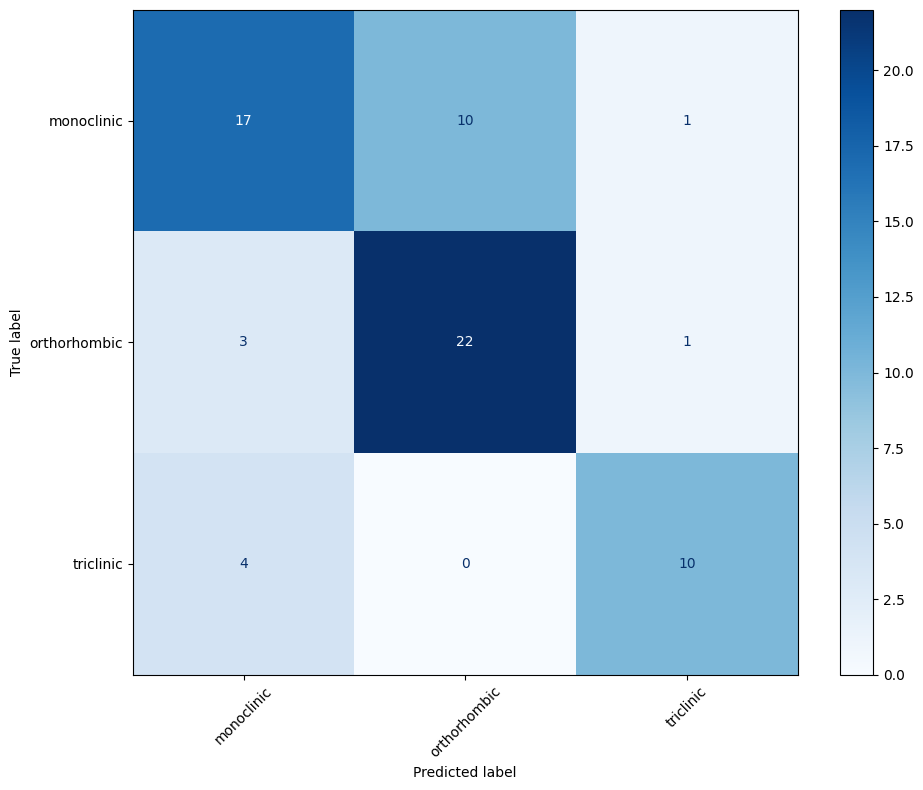

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# =========================================================
# 1. CONFUSION MATRIX
# =========================================================
cm = confusion_matrix(y_test, y_pred_tuned)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues")
plt.tight_layout()

# Save the figure with high resolution
fig.savefig('confusion_matrix.png', dpi=500, format='png')

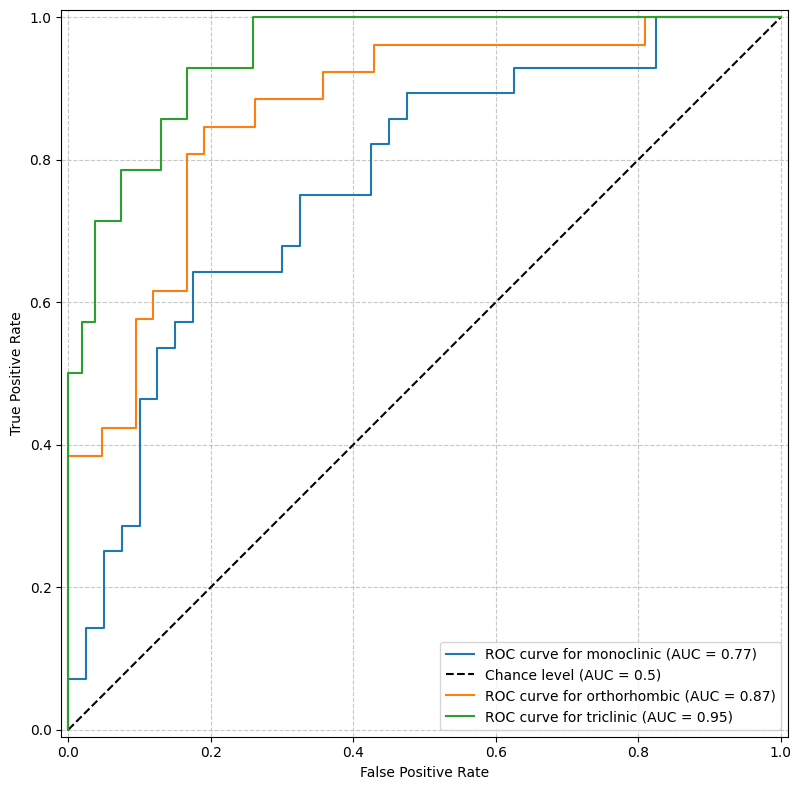

In [ ]:
from sklearn.metrics import RocCurveDisplay
from sklearn.preprocessing import LabelBinarizer

# =========================================================
# 2. MULTI-CLASS ROC CURVE
# =========================================================
label_binarizer = LabelBinarizer().fit(y_train)
y_test_binarized = label_binarizer.transform(y_test)

fig, ax = plt.subplots(figsize=(10, 8))
for i in range(len(label_encoder.classes_)): # Iterate over each class
    RocCurveDisplay.from_predictions(
        y_test_binarized[:, i],
        y_pred_proba_tuned[:, i],
        name=f"ROC curve for {label_encoder.classes_[i]}",
        ax=ax,
        plot_chance_level=(i == 0) # Plot chance level only once
    )

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()

# Save the figure with high resolution
fig.savefig('multi_class_roc_curve.png', dpi=500, format='png')

### Recursive Feature Elimination (RFE) for Stacking Model

Recursive Feature Elimination (RFE) is a feature selection method that fits a model and removes the weakest features (or least important) until the specified number of features is reached. Here, we apply RFE to the `final_estimator` (Logistic Regression) of the `StackingClassifier`.

The inputs to this `final_estimator` consist of two main parts:
1. **Meta-features**: The probability predictions generated by the base estimators (XGBoost and Random Forest) for each class.
2. **Original Features**: The preprocessed input features that were passed directly to the `StackingClassifier` due to `passthrough=True`.

By applying RFE to this combined set of features, we can identify which of these (meta-features or original features) are most influential in the final decision of the stacking model.

In [ ]:
from sklearn.feature_selection import RFE
import pandas as pd

# Assuming best_stack_model is the trained ImbPipeline from RandomizedSearchCV
# Extract the StackingClassifier from the pipeline
stack_clf = best_stack_model.named_steps['model']

# Get the preprocessed and SMOTEd training data
# This is the data that the StackingClassifier itself was trained on.
X_train_processed = best_stack_model.named_steps['prep'].transform(X_train)
X_train_smoted, y_train_smoted = best_stack_model.named_steps['smote'].fit_resample(X_train_processed, y_train)

# Get the features that were fed into the final_estimator of the StackingClassifier.
# This includes the base estimator predictions and the original features (due to passthrough=True).
X_meta_features_for_final_estimator = stack_clf.transform(X_train_smoted)

# The final estimator is a Logistic Regression, which has a coef_ attribute for feature importance
final_estimator = stack_clf.final_estimator_

# Define the number of features to select. This can be tuned.
n_features_to_select = 15  # Starting with 15 features as an example

# --- Start of fix ---
# Determine the number of classes from the label encoder
num_classes = len(label_encoder.classes_)

# Get the names of the base estimators from the StackingClassifier
# Note: stack_clf.estimators is a list of (name, estimator) tuples for the base estimators
base_estimator_names = [name for name, _ in stack_clf.estimators]

# Generate names for the meta-features (predictions from base estimators)
meta_feature_names = []
for estimator_name in base_estimator_names:
    for i in range(num_classes):
        meta_feature_names.append(f"{estimator_name}_proba_class_{label_encoder.classes_[i]}")

# Get the names of the original features after preprocessing
# The preprocessor currently only has a 'num' transformer, so get_feature_names_out() works directly.
original_preprocessed_feature_names = preprocessor.get_feature_names_out()

# Combine meta-feature names and original preprocessed feature names
final_estimator_input_feature_names = meta_feature_names + list(original_preprocessed_feature_names)

# Assert that the number of feature names matches the number of columns in X_meta_features_for_final_estimator
if len(final_estimator_input_feature_names) != X_meta_features_for_final_estimator.shape[1]:
    print("Warning: Mismatch between generated feature names and actual features fed to final estimator.")
    print(f"Expected: {len(final_estimator_input_feature_names)}, Actual: {X_meta_features_for_final_estimator.shape[1]}")

# --- End of fix ---

# Initialize and fit the RFE selector
rfe_selector = RFE(estimator=final_estimator, n_features_to_select=n_features_to_select, step=1, verbose=0)
rfe_selector.fit(X_meta_features_for_final_estimator, y_train_smoted)

# Get the selected feature names and their rankings
selected_feature_indices = rfe_selector.support_
ranked_features = rfe_selector.ranking_

selected_features = [
    final_estimator_input_feature_names[i] for i, selected in enumerate(selected_feature_indices) if selected
]

print(f"RFE selected {len(selected_features)} features:")
for feature in selected_features:
    print(f"- {feature}")

# Display all features with their RFE ranking
feature_rankings_df = pd.DataFrame({
    'Feature': final_estimator_input_feature_names,
    'Rank': ranked_features
}).sort_values(by='Rank').reset_index(drop=True)

print("\nAll Features Ranked by RFE (Rank 1 being most important):")
display(feature_rankings_df)

RFE selected 15 features:
- xgb_proba_class_monoclinic
- xgb_proba_class_orthorhombic
- xgb_proba_class_triclinic
- rf_proba_class_monoclinic
- rf_proba_class_orthorhombic
- rf_proba_class_triclinic
- num__Formation Energy (eV)
- num__Band Gap (eV)
- num__Nsites
- num__Density (gm/cc)
- num__Volume
- num__el_Si
- num__mean_stoich
- num__tm_count
- num__tm_to_total

All Features Ranked by RFE (Rank 1 being most important):


,Feature,Rank
0,xgb_proba_class_monoclinic,1
1,xgb_proba_class_orthorhombic,1
2,xgb_proba_class_triclinic,1
3,rf_proba_class_monoclinic,1
4,rf_proba_class_orthorhombic,1
5,rf_proba_class_triclinic,1
6,num__Formation Energy (eV),1
7,num__Band Gap (eV),1
8,num__Density (gm/cc),1
9,num__Nsites,1


### Enhanced Stacking Model with More Diverse Base Learners

To further improve performance and potentially exceed 75% accuracy, we will build an enhanced stacking model. This new model will leverage a more diverse set of base learners, combining the best-tuned parameters for XGBoost and RandomForest with strong default/tuned parameters for CatBoost and Gradient Boosting, which were also identified as good performers in the initial comparison.

In [ ]:
from sklearn.ensemble import StackingClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np

# Define the enhanced stacking model with more base estimators and tuned parameters
stack_model_enhanced = StackingClassifier(
    estimators=[
        ('xgb', XGBClassifier(
            n_estimators=302, # Tuned from previous RandomizedSearchCV
            max_depth=7,    # Tuned from previous RandomizedSearchCV
            learning_rate=0.0879, # Tuned from previous RandomizedSearchCV
            eval_metric='mlogloss',
            random_state=42
        )),
        ('rf', RandomForestClassifier(
            n_estimators=406, # Tuned from previous RandomizedSearchCV
            max_depth=17,   # Tuned from previous RandomizedSearchCV
            min_samples_split=8, # Tuned from previous RandomizedSearchCV
            random_state=42,
            n_jobs=-1
        )),
        ('cat', CatBoostClassifier(
            iterations=400, # From initial param_grids
            depth=8,        # From initial param_grids
            learning_rate=0.05, # From initial param_grids
            verbose=0,
            random_state=42
        )),
        ('gb', GradientBoostingClassifier(
            n_estimators=300, # From initial param_grids
            max_depth=7,      # From initial param_grids
            learning_rate=0.1,  # From initial param_grids
            random_state=42
        ))
    ],
    final_estimator=LogisticRegression(
        max_iter=3000,
        C=0.849 # Tuned from previous RandomizedSearchCV
    ),
    cv=5,
    n_jobs=-1, # Use all available cores for base estimators where possible
    passthrough=True # Pass original features to final estimator
)

# Create the full pipeline with preprocessing and SMOTE
stack_pipe_enhanced = ImbPipeline([
    ('prep', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', stack_model_enhanced)
])

print("Training enhanced stacking model...")
stack_pipe_enhanced.fit(X_train, y_train)
print("Training complete.")

# Make predictions and evaluate the model
y_pred_enhanced = stack_pipe_enhanced.predict(X_test)
y_pred_proba_enhanced = stack_pipe_enhanced.predict_proba(X_test)

acc_enhanced = accuracy_score(y_test, y_pred_enhanced)
prec_enhanced = precision_score(y_test, y_pred_enhanced, average='weighted', zero_division=0)
rec_enhanced = recall_score(y_test, y_pred_enhanced, average='weighted', zero_division=0)
f1_enhanced = f1_score(y_test, y_pred_enhanced, average='weighted', zero_division=0)
roc_auc_enhanced = roc_auc_score(y_test, y_pred_proba_enhanced, average='weighted', multi_class='ovr')

print("\n--- Enhanced Stacking Model Results ---")
print("Accuracy :", round(acc_enhanced, 4))
print("Precision:", round(prec_enhanced, 4))
print("Recall   :", round(rec_enhanced, 4))
print("F1       :", round(f1_enhanced, 4))
print("ROC_AUC  :", round(roc_auc_enhanced, 4))


Training enhanced stacking model...
Training complete.

--- Enhanced Stacking Model Results ---
Accuracy : 0.7206
Precision: 0.722
Recall   : 0.7206
F1       : 0.7169
ROC_AUC  : 0.8438


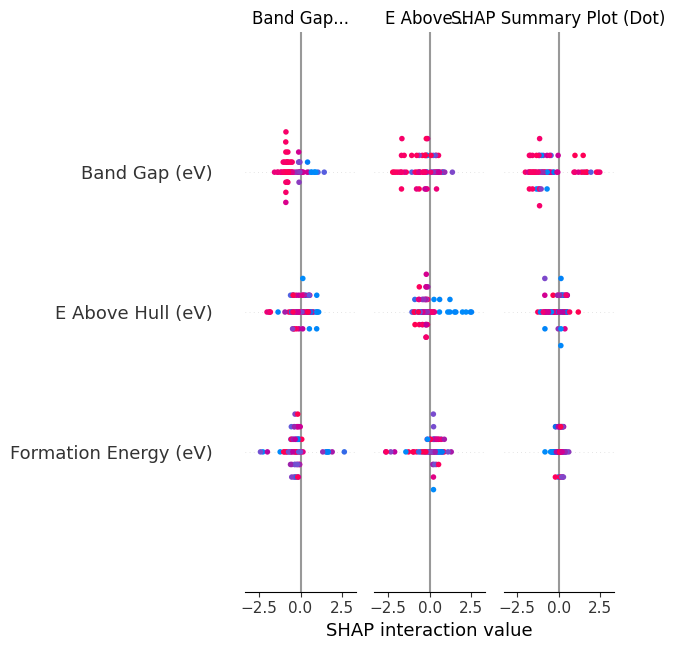

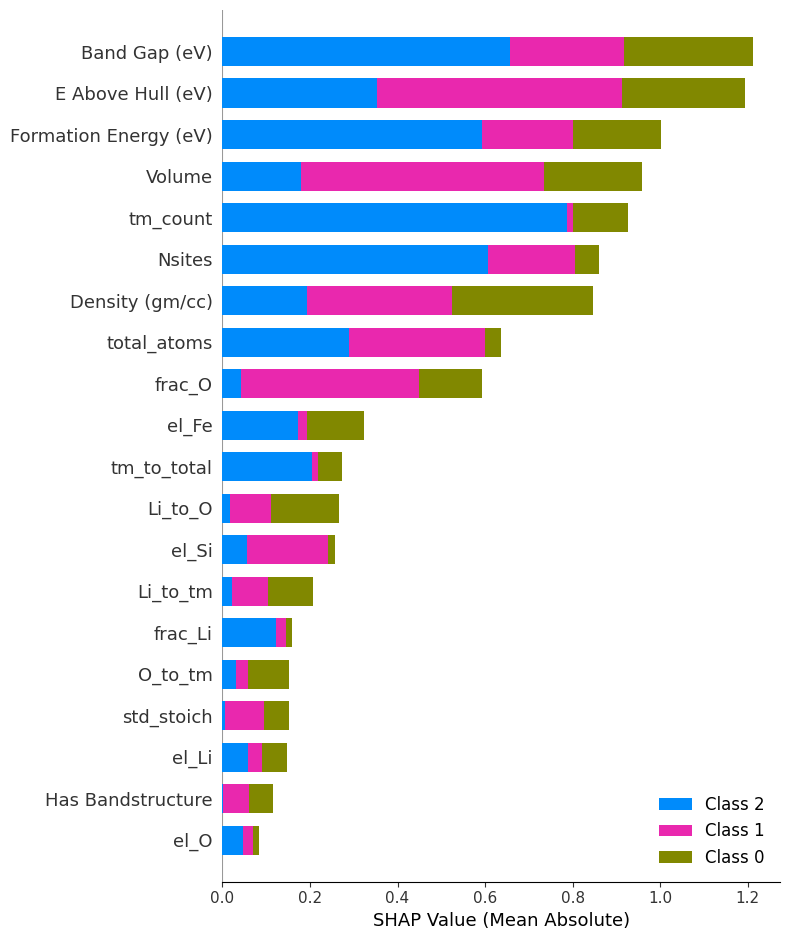

SHAP summary plots saved as 'shap_summary_dot_plot.png' and 'shap_summary_bar_plot.png' with 500 dpi.


In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# transform with preprocessing only
X_test_transformed = stack_pipe.named_steps["prep"].transform(X_test)

if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

# get trained xgb from stacking model
trained_stack = stack_pipe.named_steps["model"]
xgb_model = trained_stack.named_estimators_["xgb"]

explainer = shap.TreeExplainer(xgb_model)

X_sample = X_test_transformed[:100]
shap_values = explainer.shap_values(X_sample)

feature_names = X.columns.tolist()

# Generate and save the SHAP summary dot plot
if isinstance(shap_values, list):
    shap_values_avg = np.mean(np.abs(np.stack(shap_values)), axis=0)
    shap.summary_plot(shap_values_avg, X_sample, feature_names=feature_names, show=False)
else:
    shap.summary_plot(shap_values, X_sample, feature_names=feature_names, show=False)
plt.title('SHAP Summary Plot (Dot)')
plt.tight_layout()
plt.savefig('shap_summary_dot_plot.png', dpi=500, bbox_inches='tight')
plt.show() # Display the plot
plt.close()

# Generate and save the SHAP summary bar plot
if isinstance(shap_values, list):
    shap_values_avg = np.mean(np.abs(np.stack(shap_values)), axis=0)
    shap.summary_plot(shap_values_avg, X_sample, feature_names=feature_names, plot_type="bar", show=False)
else:
    shap.summary_plot(shap_values, X_sample, feature_names=feature_names, plot_type="bar", show=False)
plt.xlabel('SHAP Value (Mean Absolute)')
plt.tight_layout()
plt.savefig('shap_summary_bar_plot.png', dpi=500, bbox_inches='tight')
plt.show() # Display the plot
plt.close()

print("SHAP summary plots saved as 'shap_summary_dot_plot.png' and 'shap_summary_bar_plot.png' with 500 dpi.")

In [ ]:
if isinstance(shap_values, list):
    # For multi-output models, shap_values is a list of arrays, one per output
    # We average the absolute SHAP values across outputs and then across samples
    shap_array = np.stack([np.abs(s) for s in shap_values])
    mean_importance = np.mean(shap_array, axis=(0, 2)) # Average across outputs (axis 0) and samples (axis 2)
else:
    # For single-output models, shap_values is a single array
    # We average the absolute SHAP values across samples and classes (if multi-class)
    shap_array = np.abs(shap_values)
    # If shap_array is 3D (samples, features, classes), average over samples (axis 0) and classes (axis 2)
    if shap_array.ndim == 3:
        mean_importance = np.mean(shap_array, axis=(0, 2))
    else:
        # If shap_array is 2D (samples, features), average over samples (axis 0)
        mean_importance = np.mean(shap_array, axis=0)

shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "MeanAbsSHAP": mean_importance
}).sort_values("MeanAbsSHAP", ascending=False)

print(shap_importance.head(20))

                  Feature  MeanAbsSHAP
2           Band Gap (eV)     0.404404
1       E Above Hull (eV)     0.397811
0   Formation Energy (eV)     0.333715
5                  Volume     0.319457
19               tm_count     0.308903
3                  Nsites     0.286771
4         Density (gm/cc)     0.281935
14            total_atoms     0.211801
23                 frac_O     0.197709
8                   el_Fe     0.107891
40            tm_to_total     0.090862
39                Li_to_O     0.088543
12                  el_Si     0.085641
37               Li_to_tm     0.069297
22                frac_Li     0.052861
38                O_to_tm     0.050845
18             std_stoich     0.050817
9                   el_Li     0.049506
6       Has Bandstructure     0.038546
11                   el_O     0.027659


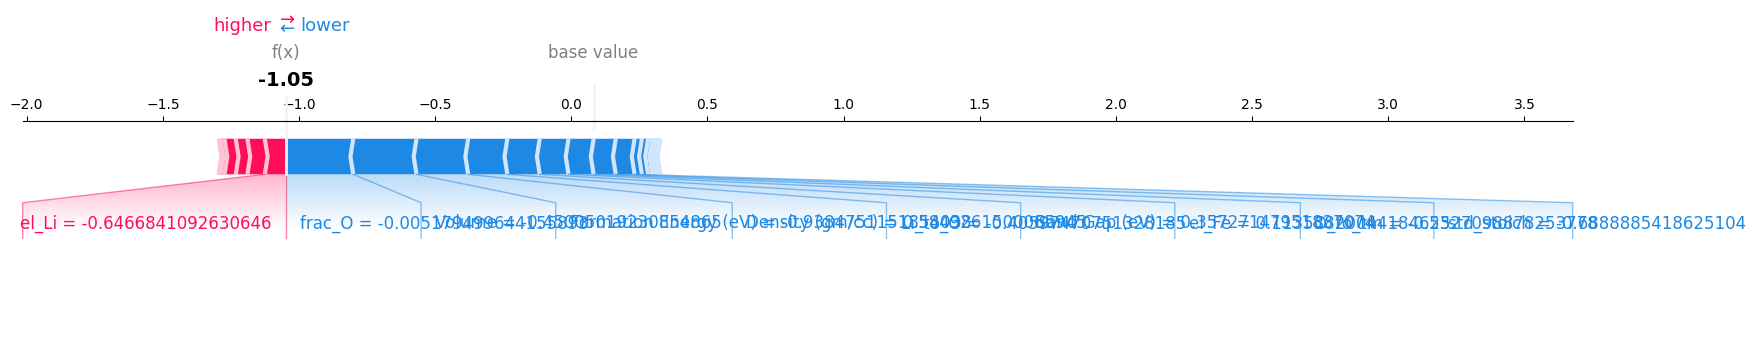

In [ ]:
sample_idx = 0
class_id = 0 # Choose a specific class to visualize, e.g., the first class

if isinstance(shap_values, list):
    # This branch is typically for multi-output models where shap_values is a list of arrays,
    # each array corresponding to a class (e.g., from some sklearn models).
    # Here, shap_values[class_id] refers to the SHAP values for that class across all samples.
    shap.force_plot(
        explainer.expected_value[class_id],
        shap_values[class_id][sample_idx],
        X_sample[sample_idx],
        feature_names=feature_names,
        matplotlib=True
    )
else:
    # This branch is for when shap_values is a 3D numpy array (samples, features, classes),
    # which is common for multi-class TreeExplainer results from models like XGBoost.
    shap.force_plot(
        explainer.expected_value[class_id], # Expected value for the selected class
        shap_values[sample_idx, :, class_id], # SHAP values for the selected sample and class
        X_sample[sample_idx],
        feature_names=feature_names,
        matplotlib=True
    )
plt.show() # Display the plot

In [ ]:
from sklearn.inspection import permutation_importance
import pandas as pd

# Assuming best_enhanced_stack_model is the tuned enhanced stacking model
# from the previous RandomizedSearchCV step

print("Calculating Permutation Importance...")

# Perform permutation importance
perm_importance = permutation_importance(
    best_enhanced_stack_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1, # Use all available cores
    scoring='accuracy'
)

# Create a DataFrame for better visualization
perm_importance_df = pd.DataFrame({
    'Feature': X.columns, # Use original feature names from X
    'Importance_Mean': perm_importance.importances_mean,
    'Importance_Std': perm_importance.importances_std
}).sort_values(by='Importance_Mean', ascending=False)

print("Permutation Importance Results (Top 20):")
display(perm_importance_df.head(20))

Calculating Permutation Importance...
Permutation Importance Results (Top 20):


,Feature,Importance_Mean,Importance_Std
39,Li_to_O,0.108824,0.014997
3,Nsites,0.092647,0.034832
12,el_Si,0.086765,0.031161
5,Volume,0.076471,0.026956
4,Density (gm/cc),0.050000,0.033663
2,Band Gap (eV),0.044118,0.037203
0,Formation Energy (eV),0.042647,0.025851
6,Has Bandstructure,0.036765,0.017708
40,tm_to_total,0.027941,0.025000
19,tm_count,0.027941,0.021260


In [1]:
!pip freeze > requirements.txt